In [67]:
!pip install optuna
!pip install lightgbm optuna --quiet
!pip install mlflow

'c:\Users\ababi\OneDrive\Desktop\AI_Platform\.venv\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.
'c:\Users\ababi\OneDrive\Desktop\AI_Platform\.venv\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.
'c:\Users\ababi\OneDrive\Desktop\AI_Platform\.venv\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from scipy import stats

# MLflow
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.pytorch

# Models
import xgboost as xgb
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sklearn utilities
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [69]:
# MLflow config — file-based, no server needed
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("walmart_sales_forecast")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Setup complete
PyTorch version: 2.11.0+cpu
GPU available: False
Using device: cpu


In [70]:
df = pd.read_csv('../data/walmart_cleaned.csv')
df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
1,1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
2,2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
3,3,1,2010-02-05,0,45.0,37.44,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
4,4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    421570 non-null  int64  
 1   Store         421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   IsHoliday     421570 non-null  int64  
 4   Dept          421570 non-null  float64
 5   Weekly_Sales  421570 non-null  float64
 6   Temperature   421570 non-null  float64
 7   Fuel_Price    421570 non-null  float64
 8   MarkDown1     421570 non-null  float64
 9   MarkDown2     421570 non-null  float64
 10  MarkDown3     421570 non-null  float64
 11  MarkDown4     421570 non-null  float64
 12  MarkDown5     421570 non-null  float64
 13  CPI           421570 non-null  float64
 14  Unemployment  421570 non-null  float64
 15  Type          421570 non-null  int64  
 16  Size          421570 non-null  int64  
dtypes: float64(11), int64(5), object(1)
memory usage

In [72]:
#delete unnecessary column 0
df.drop(columns=["Unnamed: 0"], inplace=True)

In [73]:
# Handling the Date and Time
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Cast Dept to int (it came as float64)
df["Dept"] = df["Dept"].astype(int)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Stores: {df['Store'].nunique()}")
print(f"Departments: {df['Dept'].nunique()}")
print(f"Weeks: {df['Date'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSales stats:\n{df['Weekly_Sales'].describe()}")


Shape: (421570, 16)
Date range: 2010-02-05 → 2012-10-26
Stores: 45
Departments: 81
Weeks: 143

Missing values:
Store           0
Date            0
IsHoliday       0
Dept            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

Sales stats:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [74]:
# Noise Detection
# We detect noise before touching the data.
# Detecting AFTER cleaning defeats the purpose —
# need to see what you're dealing with first.
# Three checks:
# 1. Negative sales — data errors (returns > sales on that week)
# 2. Z-score outliers — statistically extreme values per group
# 3. Coefficient of Variation — overall noise level of the series

print("=" * 50)
print("NOISE DETECTION REPORT")
print("=" * 50)

# Check 1: Negatives
neg_count = (df["Weekly_Sales"] < 0).sum()
neg_pct = neg_count / len(df) * 100
print(f"\nNegative sales rows : {neg_count:,} ({neg_pct:.3f}%)")

# Check 2: Z-score outliers per Store+Dept group
df["_zscore"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].transform(
    lambda x: np.abs(stats.zscore(x, nan_policy="omit"))
)
outliers = df[df["_zscore"] > 3]
print(f"Z-score outliers    : {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

# Check 3: Coefficient of Variation
cv = df["Weekly_Sales"].std() / df["Weekly_Sales"].mean() * 100
print(f"Coefficient of Var  : {cv:.1f}% ({'High noise' if cv > 80 else 'Acceptable'})")

NOISE DETECTION REPORT

Negative sales rows : 1,285 (0.305%)
Z-score outliers    : 6,014 (1.43%)
Coefficient of Var  : 142.1% (High noise)


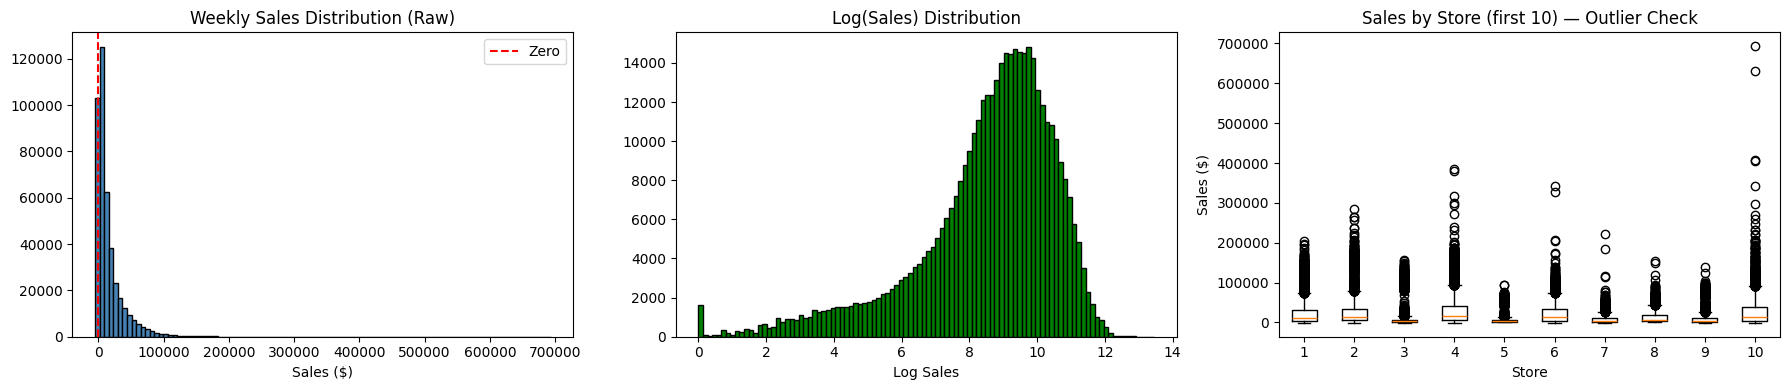

In [75]:
# Visual check
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["Weekly_Sales"], bins=100, color="steelblue", edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--", label="Zero")
axes[0].set_title("Weekly Sales Distribution (Raw)")
axes[0].set_xlabel("Sales ($)")
axes[0].legend()

axes[1].hist(
    np.log1p(df["Weekly_Sales"].clip(lower=0)),
    bins=100, color="green", edgecolor="black"
)
axes[1].set_title("Log(Sales) Distribution")
axes[1].set_xlabel("Log Sales")

axes[2].boxplot(
    [df[df["Store"] == s]["Weekly_Sales"].values
     for s in df["Store"].unique()[:10]],
    labels=[str(s) for s in df["Store"].unique()[:10]]
)
axes[2].set_title("Sales by Store (first 10) — Outlier Check")
axes[2].set_xlabel("Store")
axes[2].set_ylabel("Sales ($)")

plt.tight_layout()
plt.savefig("noise_detection.png", dpi=150, bbox_inches="tight")
plt.show()

df = df.drop(columns=["_zscore"])

In [76]:
#cleaning the noise
#deleting negative sales
before = len(df)
df = df[df["Weekly_Sales"] >= 0].copy()
print(f"Removed {before - len(df):,} negative sales rows")


Removed 1,285 negative sales rows


In [77]:
# Winsorize at 99th percentile per Store+Dept group
def winsorize_group(x):
    upper = x.quantile(0.99)
    return x.clip(upper=upper)

df["Weekly_Sales"] = df.groupby(
    ["Store", "Dept"]
)["Weekly_Sales"].transform(winsorize_group)

print(f"Winsorized outliers at 99th percentile per Store+Dept")
print(f"Final shape: {df.shape}")
print(f"Sales range after cleaning: {df['Weekly_Sales'].min():.2f} → {df['Weekly_Sales'].max():.2f}")


Winsorized outliers at 99th percentile per Store+Dept
Final shape: (420285, 16)
Sales range after cleaning: 0.00 → 535762.44


In [78]:
#feature engineering
MARKDOWN_COLS = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

#Date features
df["year"]        = df["Date"].dt.year
df["month"]       = df["Date"].dt.month
df["week_of_year"]= df["Date"].dt.isocalendar().week.astype(int)
df["quarter"]     = df["Date"].dt.quarter


In [79]:
#Holiday decomposition
super_bowl   = pd.to_datetime(["2010-02-12","2011-02-11","2012-02-10","2013-02-08"])
labor_day    = pd.to_datetime(["2010-09-10","2011-09-09","2012-09-07","2013-09-06"])
thanksgiving = pd.to_datetime(["2010-11-26","2011-11-25","2012-11-23","2013-11-29"])
christmas    = pd.to_datetime(["2010-12-31","2011-12-30","2012-12-28","2013-12-27"])

df["is_super_bowl"]   = df["Date"].isin(super_bowl).astype(int)
df["is_labor_day"]    = df["Date"].isin(labor_day).astype(int)
df["is_thanksgiving"] = df["Date"].isin(thanksgiving).astype(int)
df["is_christmas"]    = df["Date"].isin(christmas).astype(int)



In [80]:
# --- MarkDown features ---
df["total_markdown"] = df[MARKDOWN_COLS].sum(axis=1)
df["has_promotion"]  = (df["total_markdown"] > 0).astype(int)

#Lag features (per Store+Dept group)
grp = df.groupby(["Store", "Dept"])["Weekly_Sales"]

df["lag_1"]  = grp.shift(1)
df["lag_2"]  = grp.shift(2)
df["lag_4"]  = grp.shift(4)
df["lag_52"] = grp.shift(52)


In [81]:
#Rolling features (shift before rolling = no leakage)
df["rolling_mean_4"]  = grp.transform(lambda x: x.shift(1).rolling(4).mean())
df["rolling_mean_12"] = grp.transform(lambda x: x.shift(1).rolling(12).mean())
df["rolling_std_4"]   = grp.transform(lambda x: x.shift(1).rolling(4).std())

#Sales momentum
df["sales_trend"] = df["lag_1"] / (df["rolling_mean_4"] + 1e-8)

# Drop rows with NaN from lag/rolling
# Rows at the start of each Store+Dept group won't have 52
# weeks of history. We drop them — they'd corrupt training.
before = len(df)
df = df.dropna()
print(f"Dropped {before - len(df):,} rows (insufficient lag history)")
print(f"Final shape: {df.shape}")


Dropped 159,950 rows (insufficient lag history)
Final shape: (260335, 34)


In [82]:
#defining feature
FEATURES = [
    # Store identity
    "Store", "Dept", "Type", "Size",
    # Economic
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    # Promotions
    "total_markdown", "has_promotion",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    # Holidays
    "IsHoliday", "is_super_bowl", "is_labor_day",
    "is_thanksgiving", "is_christmas",
    # Date
    "year", "month", "week_of_year", "quarter",
    # Lags
    "lag_1", "lag_2", "lag_4", "lag_52",
    # Rolling
    "rolling_mean_4", "rolling_mean_12", "rolling_std_4",
    # Momentum
    "sales_trend",
]

TARGET = "Weekly_Sales"

X = df[FEATURES].copy()
y = df[TARGET].copy()

In [83]:
#splitting the data
train_size = int(len(df) * 0.8)
cutoff_date = df["Date"].iloc[train_size]

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train: {len(X_train):,} rows | up to {cutoff_date.date()}")
print(f"Test:  {len(X_test):,}  rows | from {cutoff_date.date()}")
print(f"Features: {len(FEATURES)}")

Train: 208,268 rows | up to 2012-04-06
Test:  52,067  rows | from 2012-04-06
Features: 32


In [84]:
#evaluation Helper
# Centralized metrics so all 3 models use identical
# computation. MAPE gives interpretable % error.
# Error % uses dataset mean as denominator for context.

def compute_metrics(y_true, y_pred, avg_sales):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    err_pct = (mae / avg_sales) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape, "error_pct": err_pct}

def print_metrics(name, metrics):
    print(f"\n{'='*40}")
    print(f"  {name} Results")
    print(f"{'='*40}")
    print(f"  MAE      : {metrics['mae']:>12,.2f}")
    print(f"  RMSE     : {metrics['rmse']:>12,.2f}")
    print(f"  MAPE     : {metrics['mape']:>11.2f}%")
    print(f"  Error %  : {metrics['error_pct']:>11.2f}%")

AVG_SALES = y.mean()
print(f"Average Weekly Sales: ${AVG_SALES:,.2f}")

Average Weekly Sales: $16,410.76


In [85]:
#XGboost+optuna

In [86]:
def xgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 800),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.0, 2.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
        "random_state"     : SEED,
        "tree_method"      : "hist",
        "device"           : "cuda" if torch.cuda.is_available() else "cpu",
        "verbosity"        : 0,
    }
    model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    preds = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

print("Tuning XGBoost with Optuna (30 trials)...")
xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"Best XGBoost RMSE: {xgb_study.best_value:,.2f}")
print(f"Best params: {xgb_study.best_params}")

Tuning XGBoost with Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost RMSE: 2,258.82
Best params: {'n_estimators': 570, 'max_depth': 8, 'learning_rate': 0.08183789541668933, 'subsample': 0.7120275054496303, 'colsample_bytree': 0.9313977150889684, 'reg_alpha': 0.9032811176721034, 'reg_lambda': 1.2220442970987146, 'min_child_weight': 5}


In [87]:
#calculating the RSME % aganist data size (to determine good or bad)
#| RMSE %    | Interpretation |
#| --------- | --------------
#  < 10%     | 🔥 Excellent
#  10% – 20% | ✅ Good
#  20% – 30% | ⚠️ Acceptable
#  > 30%     | ❌ Weak model

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Total cells: {df.size}")
print("Mean:", df["Weekly_Sales"].mean())
print("Std:", df["Weekly_Sales"].std())
print("Min:", df["Weekly_Sales"].min())
print("Max:", df["Weekly_Sales"].max())
rmse = 2264.43  # replace with your RMSE

mean_sales = df["Weekly_Sales"].mean()

rmse_percentage = (rmse / mean_sales) * 100

print(f"RMSE: {rmse}")
print(f"Mean Weekly_Sales: {mean_sales}")
print(f"RMSE %: {rmse_percentage:.2f}%")

Rows: 260335
Columns: 34
Total cells: 8851390
Mean: 16410.75880729445
Std: 22647.5189140634
Min: 0.0
Max: 535762.4428000029
RMSE: 2264.43
Mean Weekly_Sales: 16410.75880729445
RMSE %: 13.80%


Best XGBoost params:
{'n_estimators': 570, 'max_depth': 8, 'learning_rate': 0.08183789541668933, 'subsample': 0.7120275054496303, 'colsample_bytree': 0.9313977150889684, 'reg_alpha': 0.9032811176721034, 'reg_lambda': 1.2220442970987146, 'min_child_weight': 5, 'random_state': 42, 'tree_method': 'hist', 'device': 'cpu', 'verbosity': 0}

[RUN 1] Started metrics run
Run ID: 87eca849380247029edfa323c6c2653e

  XGBoost Results
  MAE      :     1,021.66
  RMSE     :     2,258.82
  MAPE     : 23647289.92%
  Error %  :        6.23%


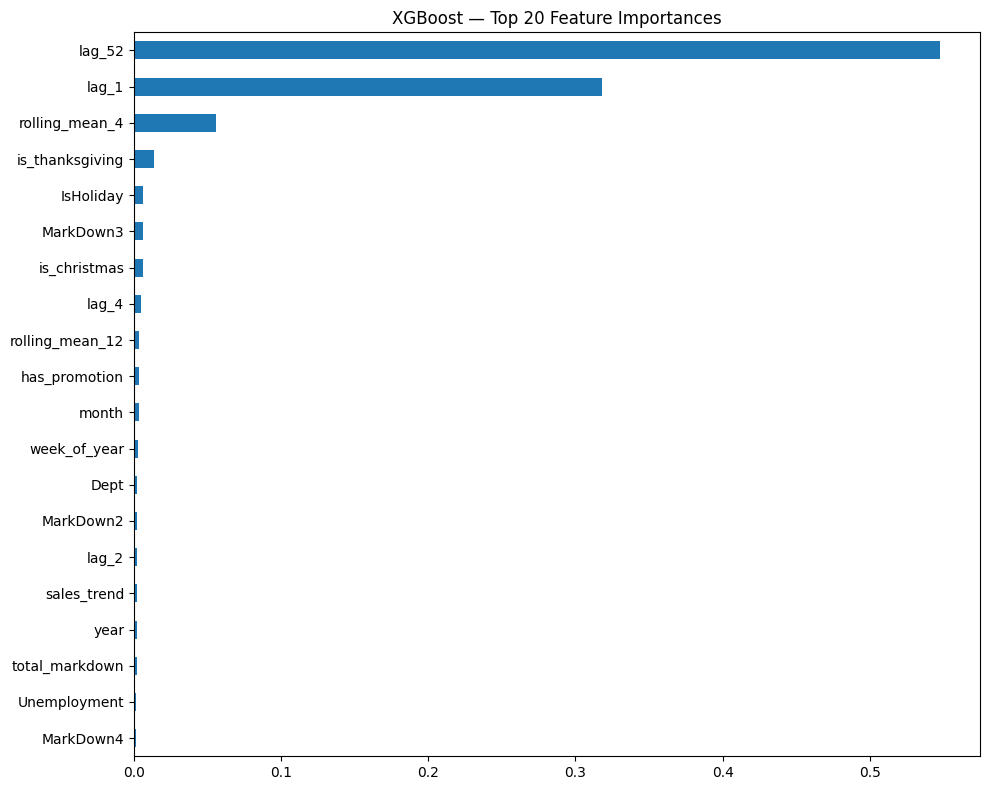

[RUN 1] Metrics/artifacts logged successfully
[RUN 1] Run ID: 87eca849380247029edfa323c6c2653e


2026/04/01 22:08:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[RUN 2] Started model logging run
Run ID: a262e5b434f643958cbf3d938d2200eb
[RUN 2] About to log model artifact...


2026/04/01 22:08:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/01 22:11:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\ababi\AppData\Local\Temp\tmpinl4r2h7\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


[RUN 2] Model logged successfully
[RUN 2] Run ID: a262e5b434f643958cbf3d938d2200eb

Done.
Metrics Run ID : 87eca849380247029edfa323c6c2653e
Model Run ID   : a262e5b434f643958cbf3d938d2200eb
Use this in API if model artifact appears:
runs:/a262e5b434f643958cbf3d938d2200eb/model


In [88]:
# ================================
# Final XGBoost Training + Robust MLflow Logging
# ================================

import traceback
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import torch

# تأكد أن MLflow يكتب داخل مشروعك
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("walmart_sales_forecast")

# 1) Best params from Optuna
xgb_best = xgb_study.best_params.copy()
xgb_best.update({
    "random_state": SEED,
    "tree_method": "hist",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "verbosity": 0,
})

print("Best XGBoost params:")
print(xgb_best)

# ================================
# RUN 1: Train + metrics + artifacts
# ================================
with mlflow.start_run(run_name="XGBoost_final_metrics") as metrics_run:

    print("\n[RUN 1] Started metrics run")
    print("Run ID:", metrics_run.info.run_id)

    xgb_model = xgb.XGBRegressor(**xgb_best, early_stopping_rounds=50)

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_preds = xgb_model.predict(X_test)
    xgb_metrics = compute_metrics(y_test.values, xgb_preds, AVG_SALES)

    print_metrics("XGBoost", xgb_metrics)

    # Log params + metrics
    mlflow.log_param("model_type", "xgboost")
    mlflow.log_params(xgb_best)
    mlflow.log_metrics(xgb_metrics)

    # Feature importance plot
    fig, ax = plt.subplots(figsize=(10, 8))
    importances = pd.Series(
        xgb_model.feature_importances_, index=FEATURES
    ).sort_values(ascending=False)[:20]

    importances.plot(kind="barh", ax=ax)
    ax.set_title("XGBoost — Top 20 Feature Importances")
    ax.invert_yaxis()
    plt.tight_layout()

    mlflow.log_figure(fig, "xgb_feature_importance.png")
    plt.show()

    # Save config artifact
    cfg = {
        "features": FEATURES,
        "model_type": "xgboost",
        "run_type": "metrics_only"
    }
    joblib.dump(cfg, "xgb_config.pkl")
    mlflow.log_artifact("xgb_config.pkl")

    METRICS_RUN_ID = mlflow.active_run().info.run_id
    print("[RUN 1] Metrics/artifacts logged successfully")
    print("[RUN 1] Run ID:", METRICS_RUN_ID)

# ================================
# RUN 2: Log the actual trained model only
# ================================
with mlflow.start_run(run_name="XGBoost_model_artifact") as model_run:

    print("\n[RUN 2] Started model logging run")
    print("Run ID:", model_run.info.run_id)
    print("[RUN 2] About to log model artifact...")

    # log useful linkage info
    mlflow.log_param("model_type", "xgboost")
    mlflow.log_param("source_metrics_run_id", METRICS_RUN_ID)

    try:
        mlflow.sklearn.log_model(
            sk_model=xgb_model,
            artifact_path="model"
        )
        print("[RUN 2] Model logged successfully")

    except Exception as e:
        print("[RUN 2] ERROR while logging model")
        print("Error message:", str(e))
        traceback.print_exc()

    MODEL_RUN_ID = mlflow.active_run().info.run_id
    print("[RUN 2] Run ID:", MODEL_RUN_ID)

print("\nDone.")
print("Metrics Run ID :", METRICS_RUN_ID)
print("Model Run ID   :", MODEL_RUN_ID)
print("Use this in API if model artifact appears:")
print(f'runs:/{MODEL_RUN_ID}/model')

In [89]:
#light GBM +optuna

def lgb_objective(trial):
    params = {
        "objective"        : "regression",
        "metric"           : "rmse",
        "verbosity"        : -1,
        "boosting_type"    : "gbdt",
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1000),
        "max_depth"        : trial.suggest_int("max_depth", 4, 12),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 200),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.0, 1.0),
        "random_state"     : SEED,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    preds = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

print("Tuning LightGBM with Optuna (50 trials)...")
lgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"Best LightGBM RMSE: {lgb_study.best_value:,.2f}")
print(f"Best params: {lgb_study.best_params}")

Tuning LightGBM with Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best LightGBM RMSE: 2,317.66
Best params: {'n_estimators': 492, 'max_depth': 12, 'num_leaves': 188, 'learning_rate': 0.10511719423366594, 'min_child_samples': 32, 'subsample': 0.7774711035787524, 'colsample_bytree': 0.6825410771584358, 'reg_alpha': 0.4031635593444857, 'reg_lambda': 0.7356966999249858}


2026/04/01 22:40:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  LightGBM Results
  MAE      :     1,055.29
  RMSE     :     2,317.66
  MAPE     : 19955353.08%
  Error %  :        6.43%


2026/04/01 22:40:13 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/01 22:42:16 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\ababi\AppData\Local\Temp\tmpbfdz66u_\model, flavor: lightgbm). Fall back to return ['lightgbm==4.6.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
Registered model 'sales_forecast_lightgbm' already exists. Creating a new version of this model...
Created version '6' of model 'sales_forecast_lightgbm'.


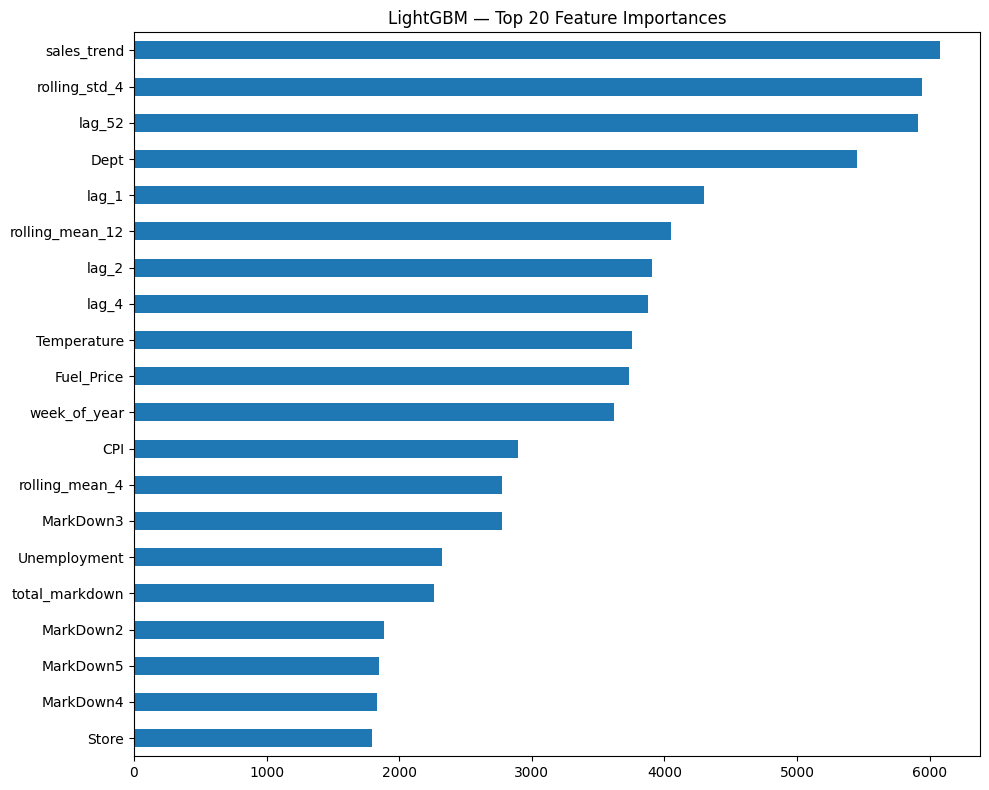

MLflow Run ID: 3232119f9e794595af4aea946e5646aa


In [90]:
#Train Final LightGBM + Log to MLflow

lgb_best = lgb_study.best_params
lgb_best.update({
    "objective"    : "regression",
    "metric"       : "rmse",
    "verbosity"    : -1,
    "random_state" : SEED,
})

with mlflow.start_run(run_name="LightGBM_final"):

    lgb_model = lgb.LGBMRegressor(**lgb_best)
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    lgb_preds   = lgb_model.predict(X_test)
    lgb_metrics = compute_metrics(y_test.values, lgb_preds, AVG_SALES)
    print_metrics("LightGBM", lgb_metrics)

    mlflow.log_param("model_type", "lightgbm")
    mlflow.log_params(lgb_best)
    mlflow.log_metrics(lgb_metrics)

    mlflow.lightgbm.log_model(
        lgb_model,
        artifact_path="model",
        registered_model_name="sales_forecast_lightgbm"
    )

    # Feature importance
    fig, ax = plt.subplots(figsize=(10, 8))
    lgb_importance = pd.Series(
        lgb_model.feature_importances_, index=FEATURES
    ).sort_values(ascending=False)[:20]
    lgb_importance.plot(kind="barh", ax=ax)
    ax.set_title("LightGBM — Top 20 Feature Importances")
    ax.invert_yaxis()
    plt.tight_layout()
    mlflow.log_figure(fig, "lgb_feature_importance.png")
    plt.show()

    joblib.dump({"features": FEATURES, "model_type": "lightgbm"}, "lgb_config.pkl")
    mlflow.log_artifact("lgb_config.pkl")

    LGB_RUN_ID = mlflow.active_run().info.run_id
    print(f"MLflow Run ID: {LGB_RUN_ID}")

In [91]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# =========================
# 📊 DATA OVERVIEW
# =========================
print("\n===== DATA OVERVIEW =====")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Total cells: {df.size}")

mean_sales   = df["Weekly_Sales"].mean()
median_sales = df["Weekly_Sales"].median()
std_sales    = df["Weekly_Sales"].std()
min_sales    = df["Weekly_Sales"].min()
max_sales    = df["Weekly_Sales"].max()

print("\n===== TARGET STATS =====")
print(f"Mean: {mean_sales:.2f}")
print(f"Median: {median_sales:.2f}")
print(f"Std: {std_sales:.2f}")
print(f"Min: {min_sales:.2f}")
print(f"Max: {max_sales:.2f}")

# =========================
# 🤖 METRICS CALCULATION
# =========================

mse  = mean_squared_error(y_test, lgb_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, lgb_preds)

rmse_percentage_mean   = (rmse / mean_sales) * 100
rmse_percentage_median = (rmse / median_sales) * 100

# =========================
# 🧠 INTERPRETATION LOGIC
# =========================

def interpret_rmse(p):
    if p < 10:
        return "🔥 Excellent"
    elif p < 20:
        return "✅ Good"
    elif p < 30:
        return "⚠️ Acceptable"
    else:
        return "❌ Weak model"

# =========================
# 🖨️ PRINT RESULTS
# =========================

print("\n===== MODEL PERFORMANCE (LightGBM) =====")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

print("\n===== RMSE INTERPRETATION =====")
print(f"RMSE % (mean): {rmse_percentage_mean:.2f}% → {interpret_rmse(rmse_percentage_mean)}")
print(f"RMSE % (median): {rmse_percentage_median:.2f}% → {interpret_rmse(rmse_percentage_median)}")


===== DATA OVERVIEW =====
Rows: 260335
Columns: 34
Total cells: 8851390

===== TARGET STATS =====
Mean: 16410.76
Median: 7994.69
Std: 22647.52
Min: 0.00
Max: 535762.44

===== MODEL PERFORMANCE (LightGBM) =====
MSE: 5371546.06
RMSE: 2317.66
MAE: 1055.29

===== RMSE INTERPRETATION =====
RMSE % (mean): 14.12% → ✅ Good
RMSE % (median): 28.99% → ⚠️ Acceptable


In [92]:
# #LSTM architecture
# SEQ_LEN = 12  # 12 weeks lookback window

# class SalesLSTM(nn.Module):
#     def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size  = input_size,
#             hidden_size = hidden_size,
#             num_layers  = num_layers,
#             dropout     = dropout if num_layers > 1 else 0.0,
#             batch_first = True   # input shape: (batch, seq, features)
#         )
#         self.dropout = nn.Dropout(dropout)
#         self.fc = nn.Linear(hidden_size, 1)

#     def forward(self, x):
#         # x shape: (batch_size, seq_len, input_size)
#         lstm_out, _ = self.lstm(x)
#         # Take only the last timestep output
#         last_out = lstm_out[:, -1, :]
#         out = self.dropout(last_out)
#         return self.fc(out).squeeze(-1)

# print(f"LSTM class defined")
# print(f"Sequence length: {SEQ_LEN} weeks")
# print(f"Input features: {len(FEATURES)}")


In [93]:
# #Build LSTM Sequences
# # We must build sequences PER Store+Dept group.
# # If we build sequences from the flat DataFrame, we'd get
# # sequences that cross store boundaries — the LSTM would
# # see Store1+Dept1 week 10 followed by Store1+Dept2 week 1.
# # That's nonsense.

# # For each Store+Dept:
# #   - Scale X features and y target
# #   - Build overlapping windows of length SEQ_LEN
# #   - Each window [i : i+SEQ_LEN] predicts y[i+SEQ_LEN]
# #
# # We scale per-group because different stores have very
# # different sales ranges. Store A (superstore) vs Store C
# # (small neighborhood store) cannot share the same scaler.

# def build_sequences(group_df, features, target, seq_len, x_scaler, y_scaler):
#     """Build LSTM sequences for one Store+Dept group."""
#     X_vals = x_scaler.transform(group_df[features].values)
#     y_vals = y_scaler.transform(group_df[[target]].values).flatten()

#     X_seqs, y_seqs = [], []
#     for i in range(len(X_vals) - seq_len):
#         X_seqs.append(X_vals[i : i + seq_len])
#         y_seqs.append(y_vals[i + seq_len])

#     return np.array(X_seqs), np.array(y_seqs)

# # Fit scalers on training data only
# # (never fit on test data — that's data leakage)
# train_df = df.iloc[:train_size].copy()
# test_df  = df.iloc[train_size:].copy()

# lstm_x_scaler = StandardScaler()
# lstm_y_scaler = StandardScaler()

# lstm_x_scaler.fit(train_df[FEATURES].values)
# lstm_y_scaler.fit(train_df[[TARGET]].values)

# # Build sequences per Store+Dept
# X_train_seqs, y_train_seqs = [], []
# X_test_seqs,  y_test_seqs  = [], []

# groups = df.groupby(["Store", "Dept"])

# for (store, dept), group in groups:
#     group = group.sort_values("Date")

#     # Split this group's rows into train/test by date
#     grp_train = group[group["Date"] < cutoff_date]
#     grp_test  = group[group["Date"] >= cutoff_date]

#     # Need at least SEQ_LEN + 1 rows to make one sequence
#     if len(grp_train) > SEQ_LEN:
#         Xs, ys = build_sequences(
#             grp_train, FEATURES, TARGET, SEQ_LEN,
#             lstm_x_scaler, lstm_y_scaler
#         )
#         X_train_seqs.append(Xs)
#         y_train_seqs.append(ys)

#     # For test: we need SEQ_LEN rows of context before predicting
#     # So we take the last SEQ_LEN rows of train + all test rows
#     if len(grp_test) > 0 and len(grp_train) >= SEQ_LEN:
#         combined = pd.concat([grp_train.tail(SEQ_LEN), grp_test])
#         Xs, ys = build_sequences(
#             combined, FEATURES, TARGET, SEQ_LEN,
#             lstm_x_scaler, lstm_y_scaler
#         )
#         X_test_seqs.append(Xs)
#         y_test_seqs.append(ys)

# X_train_lstm = np.concatenate(X_train_seqs, axis=0)
# y_train_lstm = np.concatenate(y_train_seqs, axis=0)
# X_test_lstm  = np.concatenate(X_test_seqs,  axis=0)
# y_test_lstm  = np.concatenate(y_test_seqs,  axis=0)

# print(f"LSTM Train sequences : {X_train_lstm.shape}")
# print(f"LSTM Test sequences  : {X_test_lstm.shape}")
# print(f"  Shape format: (samples, seq_len={SEQ_LEN}, features={len(FEATURES)})")

# # Convert to PyTorch tensors
# def to_tensor(arr):
#     return torch.tensor(arr, dtype=torch.float32)

# train_dataset = TensorDataset(to_tensor(X_train_lstm), to_tensor(y_train_lstm))
# test_dataset  = TensorDataset(to_tensor(X_test_lstm),  to_tensor(y_test_lstm))

# train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

# print(f"Train batches: {len(train_loader)}")
# print(f"Test batches:  {len(test_loader)}")

In [94]:
# #LSTM Optuna: SEQ_LEN tuned by Optuna
# # Optuna now also tunes seq_len (4, 8, or 12 weeks).
# # Problem: different seq_len values produce different-sized
# # sequence arrays, so we cannot precompute sequences outside
# # the trial. We rebuild sequences inside each trial.
# # This makes each trial slower but gives Optuna full control.

# def build_sequences_for_trial(seq_len):
#     """Rebuild train/test sequences for a given seq_len."""
#     X_tr, y_tr, X_te, y_te = [], [], [], []

#     for (store, dept), group in df.groupby(["Store", "Dept"]):
#         group = group.sort_values("Date")
#         grp_train = group[group["Date"] < cutoff_date]
#         grp_test  = group[group["Date"] >= cutoff_date]

#         if len(grp_train) > seq_len:
#             Xs, ys = build_sequences(
#                 grp_train, FEATURES, TARGET, seq_len,
#                 lstm_x_scaler, lstm_y_scaler
#             )
#             X_tr.append(Xs); y_tr.append(ys)

#         if len(grp_test) > 0 and len(grp_train) >= seq_len:
#             combined = pd.concat([grp_train.tail(seq_len), grp_test])
#             Xs, ys = build_sequences(
#                 combined, FEATURES, TARGET, seq_len,
#                 lstm_x_scaler, lstm_y_scaler
#             )
#             X_te.append(Xs); y_te.append(ys)

#     return (
#         np.concatenate(X_tr), np.concatenate(y_tr),
#         np.concatenate(X_te), np.concatenate(y_te)
#     )


# def lstm_objective(trial):
#     # Optuna now owns seq_len
#     seq_len     = trial.suggest_categorical("seq_len", [4, 8, 12, 16])
#     hidden_size = trial.suggest_int("hidden_size", 64, 256)
#     num_layers  = trial.suggest_int("num_layers", 1, 3)
#     dropout     = trial.suggest_float("dropout", 0.1, 0.4)
#     lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
#     batch_size  = trial.suggest_categorical("batch_size", [256, 512, 1024])

#     # Rebuild sequences for this trial's seq_len
#     X_tr, y_tr, X_te, y_te = build_sequences_for_trial(seq_len)

#     _loader = DataLoader(
#         TensorDataset(to_tensor(X_tr), to_tensor(y_tr)),
#         batch_size=batch_size, shuffle=True
#     )
#     _test_loader = DataLoader(
#         TensorDataset(to_tensor(X_te), to_tensor(y_te)),
#         batch_size=batch_size, shuffle=False
#     )

#     model     = SalesLSTM(len(FEATURES), hidden_size, num_layers, dropout).to(DEVICE)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     loss_fn   = nn.MSELoss()

#     for epoch in range(20):
#         model.train()
#         for xb, yb in _loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             optimizer.zero_grad()
#             loss_fn(model(xb), yb).backward()
#             nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#             optimizer.step()

#     model.eval()
#     all_preds = []
#     with torch.no_grad():
#         for xb, _ in _test_loader:
#             all_preds.append(model(xb.to(DEVICE)).cpu().numpy())

#     preds = lstm_y_scaler.inverse_transform(
#         np.concatenate(all_preds).reshape(-1, 1)
#     ).flatten()
#     y_true = lstm_y_scaler.inverse_transform(
#         y_te.reshape(-1, 1)
#     ).flatten()

#     return np.sqrt(mean_squared_error(y_true, preds))


# print("Tuning LSTM with Optuna (20 trials) — seq_len included...")
# lstm_study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=SEED)
# )
# lstm_study.optimize(lstm_objective, n_trials=20, show_progress_bar=True)

# # Extract best seq_len for use in Cell 15
# BEST_SEQ_LEN = lstm_study.best_params["seq_len"]

# print(f"Best LSTM RMSE  : {lstm_study.best_value:,.2f}")
# print(f"Best seq_len    : {BEST_SEQ_LEN} weeks")
# print(f"Best params     : {lstm_study.best_params}")

In [95]:
# #Train Final LSTM + Log to MLflow
# # We use BEST_SEQ_LEN from Optuna  to rebuild the sequences at the optimal window size before training.

# # Key additions vs the tuning loop:

# # ReduceLROnPlateau: cuts learning rate by 50% when loss
# #   stops improving for 10 epochs. Optuna found the starting
# #   LR — this scheduler refines it during long training.
# #   Prevents the model from oscillating around the minimum.
# #
# # Gradient clipping (clip_grad_norm_ = 1.0):
# #   LSTM backpropagates through SEQ_LEN timesteps.
# #   Gradients multiply across each step — they can explode
# #   to NaN. Clipping caps the gradient norm at 1.0.
# #   Standard practice for any RNN/LSTM training.
# #
# # Early stopping with best weights restore:
# #   We save the model state whenever loss improves.
# #   If loss doesn't improve for PATIENCE=15 epochs, we stop
# #   and reload the best weights — not the last weights.
# #   Last weights = overfit. Best weights = generalize.
# #
# # Inverse transform before metrics:
# #   Predictions come out in scaled space (~[-3, 3]).
# #   MAE/RMSE in scaled space is meaningless.
# #   We must inverse_transform both preds and y_true
# #   before computing any metric.

# lstm_best = lstm_study.best_params
# BEST_SEQ_LEN = lstm_best["seq_len"]
# EPOCHS = 100
# PATIENCE = 15

# # Step 1: Rebuild sequences at best seq_len
# print(f"Rebuilding sequences with optimal seq_len={BEST_SEQ_LEN}...")
# X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm = build_sequences_for_trial(BEST_SEQ_LEN)

# print(f"Train sequences : {X_train_lstm.shape}")
# print(f"Test sequences  : {X_test_lstm.shape}")

# # Step 2: DataLoaders
# final_train_loader = DataLoader(
#     TensorDataset(to_tensor(X_train_lstm), to_tensor(y_train_lstm)),
#     batch_size=lstm_best["batch_size"],
#     shuffle=True
# )
# final_test_loader = DataLoader(
#     TensorDataset(to_tensor(X_test_lstm), to_tensor(y_test_lstm)),
#     batch_size=lstm_best["batch_size"],
#     shuffle=False
# )

# # Step 3: Build model from best hyperparameters
# lstm_model = SalesLSTM(
#     input_size  = len(FEATURES),
#     hidden_size = lstm_best["hidden_size"],
#     num_layers  = lstm_best["num_layers"],
#     dropout     = lstm_best["dropout"]
# ).to(DEVICE)

# optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lstm_best["lr"])

# # Halve LR when loss plateaus for 10 epochs
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     patience=10,
#     factor=0.5,
#     verbose=False
# )

# loss_fn = nn.MSELoss()

# print(f"\nModel architecture:")
# print(lstm_model)
# total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
# print(f"Trainable parameters: {total_params:,}")

# # ── Step 4: Training loop ──────────────────────────────────
# train_losses     = []
# best_val_loss    = float("inf")
# patience_counter = 0
# best_epoch       = 0

# print(f"\nTraining for up to {EPOCHS} epochs (early stopping patience={PATIENCE})...")

# for epoch in range(EPOCHS):
#     lstm_model.train()
#     epoch_loss = 0.0

#     for xb, yb in final_train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)

#         optimizer.zero_grad()
#         preds_batch = lstm_model(xb)
#         loss = loss_fn(preds_batch, yb)
#         loss.backward()

#         # Prevent exploding gradients
#         nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)

#         optimizer.step()
#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(final_train_loader)
#     train_losses.append(avg_loss)
#     scheduler.step(avg_loss)

#     # Save best weights
#     if avg_loss < best_val_loss:
#         best_val_loss    = avg_loss
#         patience_counter = 0
#         best_epoch       = epoch + 1
#         torch.save(lstm_model.state_dict(), "lstm_best.pt")
#     else:
#         patience_counter += 1

#     if (epoch + 1) % 10 == 0:
#         current_lr = optimizer.param_groups[0]["lr"]
#         print(
#             f"Epoch {epoch+1:3d}/{EPOCHS} | "
#             f"Loss: {avg_loss:.6f} | "
#             f"Best: {best_val_loss:.6f} | "
#             f"LR: {current_lr:.6f} | "
#             f"Patience: {patience_counter}/{PATIENCE}"
#         )

#     if patience_counter >= PATIENCE:
#         print(f"\nEarly stopping triggered at epoch {epoch+1}")
#         break

# # Reload best weights — not last epoch weights
# lstm_model.load_state_dict(torch.load("lstm_best.pt"))
# print(f"\nLoaded best weights from epoch {best_epoch}")

# # ── Step 5: Inference ──────────────────────────────────────
# lstm_model.eval()
# all_preds_scaled = []

# with torch.no_grad():
#     for xb, _ in final_test_loader:
#         batch_preds = lstm_model(xb.to(DEVICE)).cpu().numpy()
#         all_preds_scaled.append(batch_preds)

# # Inverse transform — convert scaled predictions back to dollars
# preds_scaled = np.concatenate(all_preds_scaled).reshape(-1, 1)
# lstm_preds   = lstm_y_scaler.inverse_transform(preds_scaled).flatten()
# y_true_lstm  = lstm_y_scaler.inverse_transform(
#     y_test_lstm.reshape(-1, 1)
# ).flatten()

# # ── Step 6: Metrics ────────────────────────────────────────
# lstm_metrics = compute_metrics(y_true_lstm, lstm_preds, AVG_SALES)
# print_metrics("LSTM", lstm_metrics)

# # ── Step 7: MLflow Logging ─────────────────────────────────
# with mlflow.start_run(run_name="LSTM_final"):

#     # Parameters
#     mlflow.log_param("model_type",   "lstm")
#     mlflow.log_param("seq_len",      BEST_SEQ_LEN)
#     mlflow.log_param("hidden_size",  lstm_best["hidden_size"])
#     mlflow.log_param("num_layers",   lstm_best["num_layers"])
#     mlflow.log_param("dropout",      lstm_best["dropout"])
#     mlflow.log_param("lr",           lstm_best["lr"])
#     mlflow.log_param("batch_size",   lstm_best["batch_size"])
#     mlflow.log_param("epochs_run",   best_epoch)
#     mlflow.log_param("n_features",   len(FEATURES))
#     mlflow.log_param("train_size",   len(X_train_lstm))
#     mlflow.log_param("test_size",    len(X_test_lstm))

#     # Metrics
#     mlflow.log_metrics(lstm_metrics)

#     # Register model
#     mlflow.pytorch.log_model(
#         lstm_model,
#         artifact_path="model",
#         registered_model_name="sales_forecast_lstm"
#     )

#     # Training loss curve
#     fig1, ax1 = plt.subplots(figsize=(10, 4))
#     ax1.plot(train_losses, color="steelblue", linewidth=1.5)
#     ax1.axvline(
#         best_epoch - 1,
#         color="red",
#         linestyle="--",
#         label=f"Best epoch ({best_epoch})"
#     )
#     ax1.set_title("LSTM Training Loss Curve")
#     ax1.set_xlabel("Epoch")
#     ax1.set_ylabel("MSE Loss")
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)
#     plt.tight_layout()
#     mlflow.log_figure(fig1, "lstm_training_curve.png")
#     plt.show()

#     # Actual vs Predicted — sample from one Store+Dept
#     results_df = pd.DataFrame({
#         "Actual"    : y_true_lstm,
#         "Predicted" : lstm_preds
#     })

#     sample_size = min(100, len(results_df))

#     fig2, axes = plt.subplots(2, 1, figsize=(14, 8))

#     axes[0].plot(
#         results_df["Actual"].values[:sample_size],
#         label="Actual", linewidth=1.5
#     )
#     axes[0].plot(
#         results_df["Predicted"].values[:sample_size],
#         label="Predicted", linestyle="--",
#         linewidth=1.5, color="orange"
#     )
#     axes[0].set_title(f"LSTM — Actual vs Predicted (first {sample_size} test samples)")
#     axes[0].set_xlabel("Sample")
#     axes[0].set_ylabel("Weekly Sales ($)")
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)

#     residuals = results_df["Actual"].values[:sample_size] - \
#                 results_df["Predicted"].values[:sample_size]
#     axes[1].bar(range(sample_size), residuals, color="red", alpha=0.5)
#     axes[1].axhline(0, color="black", linewidth=1)
#     axes[1].set_title("Residuals (Actual - Predicted)")
#     axes[1].set_xlabel("Sample")
#     axes[1].set_ylabel("Error ($)")
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     mlflow.log_figure(fig2, "lstm_forecast_vs_actual.png")
#     plt.show()

#     # Save scalers and config — required for inference in FastAPI
#     joblib.dump({
#         "x_scaler"   : lstm_x_scaler,
#         "y_scaler"   : lstm_y_scaler,
#         "features"   : FEATURES,
#         "seq_len"    : BEST_SEQ_LEN,
#         "model_type" : "lstm",
#         "hidden_size": lstm_best["hidden_size"],
#         "num_layers" : lstm_best["num_layers"],
#         "dropout"    : lstm_best["dropout"],
#     }, "lstm_config.pkl")
#     mlflow.log_artifact("lstm_config.pkl")
#     mlflow.log_artifact("lstm_best.pt")

#     LSTM_RUN_ID = mlflow.active_run().info.run_id
#     print(f"\nMLflow Run ID: {LSTM_RUN_ID}")
#     print("Artifacts saved: model, lstm_config.pkl, lstm_best.pt")
#     print("Training curve and forecast plot logged to MLflow")

In [96]:
# print("\n===== DATA OVERVIEW =====")
# print(f"Rows: {df.shape[0]}")
# print(f"Columns: {df.shape[1]}")
# print(f"Total cells: {df.size}")

# mean_sales   = df["Weekly_Sales"].mean()
# median_sales = df["Weekly_Sales"].median()
# std_sales    = df["Weekly_Sales"].std()
# min_sales    = df["Weekly_Sales"].min()
# max_sales    = df["Weekly_Sales"].max()

# print("\n===== TARGET STATS =====")
# print(f"Mean Weekly_Sales: {mean_sales:.2f}")
# print(f"Median Weekly_Sales: {median_sales:.2f}")
# print(f"Std Weekly_Sales: {std_sales:.2f}")
# print(f"Min Weekly_Sales: {min_sales:.2f}")
# print(f"Max Weekly_Sales: {max_sales:.2f}")

# # =========================
# # 🤖 LSTM METRICS
# # =========================
# mse_lstm  = mean_squared_error(y_true_lstm, lstm_preds)
# rmse_lstm = np.sqrt(mse_lstm)
# mae_lstm  = mean_absolute_error(y_true_lstm, lstm_preds)

# rmse_pct_lstm_mean   = (rmse_lstm / mean_sales) * 100
# rmse_pct_lstm_median = (rmse_lstm / median_sales) * 100

# # =========================
# # 🧠 INTERPRETATION
# # =========================
# def interpret_rmse(p):
#     if p < 10:
#         return "🔥 Excellent"
#     elif p < 20:
#         return "✅ Good"
#     elif p < 30:
#         return "⚠️ Acceptable"
#     else:
#         return "❌ Weak model"

# print("\n===== MODEL PERFORMANCE (LSTM) =====")
# print(f"MSE (LSTM): {mse_lstm:.2f}")
# print(f"RMSE (LSTM): {rmse_lstm:.2f}")
# print(f"MAE (LSTM): {mae_lstm:.2f}")

# print("\n===== RMSE INTERPRETATION (LSTM) =====")
# print(f"RMSE % (vs mean): {rmse_pct_lstm_mean:.2f}% → {interpret_rmse(rmse_pct_lstm_mean)}")
# print(f"RMSE % (vs median): {rmse_pct_lstm_median:.2f}% → {interpret_rmse(rmse_pct_lstm_median)}")

In [97]:
# # ============================================================
# # CELL 16 — Model Comparison
# # ============================================================
# # Compare all 3 models side by side.
# # This is what appears in your MLflow UI automatically —
# # this cell just prints and plots it locally too.

# comparison = pd.DataFrame({
#     "Model"    : ["XGBoost", "LightGBM", "LSTM"],
#     "MAE"      : [xgb_metrics["mae"],  lgb_metrics["mae"],  lstm_metrics["mae"]],
#     "RMSE"     : [xgb_metrics["rmse"], lgb_metrics["rmse"], lstm_metrics["rmse"]],
#     "MAPE (%)" : [xgb_metrics["mape"], lgb_metrics["mape"], lstm_metrics["mape"]],
#     "Error (%)" : [xgb_metrics["error_pct"], lgb_metrics["error_pct"], lstm_metrics["error_pct"]],
# })

# comparison = comparison.sort_values("RMSE")
# print("\n" + "="*60)
# print("MODEL COMPARISON (sorted by RMSE)")
# print("="*60)
# print(comparison.to_string(index=False))
# print(f"\nWinner: {comparison.iloc[0]['Model']}")

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# metrics_to_plot = ["MAE", "RMSE", "MAPE (%)"]
# colors = ["steelblue", "orange", "green"]

# for i, metric in enumerate(metrics_to_plot):
#     axes[i].bar(comparison["Model"], comparison[metric], color=colors)
#     axes[i].set_title(metric)
#     axes[i].set_ylabel(metric)
#     for j, val in enumerate(comparison[metric]):
#         axes[i].text(j, val * 1.01, f"{val:,.1f}", ha="center", fontsize=9)

# plt.suptitle("Model Comparison — Walmart Sales Forecast", fontsize=14)
# plt.tight_layout()
# plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

# print("\nTo view all runs in MLflow UI:")
# print("  mlflow ui --backend-store-uri file:./mlruns")
# print("  Then open: http://localhost:5000")

In [98]:
with mlflow.start_run(run_name="xgb_model_logging_test"):

    test_model = xgb.XGBRegressor(
        n_estimators=10,
        max_depth=3,
        random_state=42
    )
    test_model.fit(X_train, y_train)

    # جرّب flavor sklearn بدل xgboost
    mlflow.sklearn.log_model(test_model, artifact_path="model")

    print("Test model logged")
    print("Run ID:", mlflow.active_run().info.run_id)

2026/04/01 22:42:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 22:42:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Test model logged
Run ID: 04e638a987af4bc0ae95d2281ae51ee7
